In [2]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

import healpy as hp

sys.path.append(os.path.expanduser('~/git/desi-targets/useful'))
from isdes import get_isdes

In [3]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
target_class = 'LRG'
target_ver_str = '1.0.0'
min_nobs = 1
nside = 512

# imaging_sys_dir = '/global/cfs/cdirs/desi/users/rongpu/data/imaging_sys'
imaging_sys_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_sys'
randoms_counts_dir = os.path.join(imaging_sys_dir, 'randoms_stats/0.49.0/resolve/counts')
target_densities_dir = os.path.join(imaging_sys_dir, 'density_maps/{}/resolve'.format(target_ver_str))

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print(nside, 'Healpix size = {:.5f} sq deg'.format(pix_area))

hp_in_desi = np.load('/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_sys/misc/in_desi_healpix_ring.npy', allow_pickle=True).item()[str(nside)]

512 Healpix size = 0.01311 sq deg


## Total area in DR9

In [4]:
maskbits = []
lrgmask_str = ''

for field in ['north', 'south']:

    if field=='north' or field=='BASS+MzLS':
        photsys = 'N'
    else:
        photsys = 'S'

    maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits])+lrgmask_str)))
    maps = maps[maps['n_randoms']>0]

    maps['PHOTSYS'] = photsys

    if field=='north':
        maps_north = maps.copy()
    else:
        maps_south = maps.copy()

########## Combine the two maps; proper handling of overlapping pixels ##########

pix_overlap = np.intersect1d(maps_north['HPXPIXEL'], maps_south['HPXPIXEL'])
mask = np.in1d(maps_north['HPXPIXEL'], pix_overlap)
maps_overlap_north = maps_north[mask]
maps_north = maps_north[~mask]
mask = np.in1d(maps_south['HPXPIXEL'], pix_overlap)
maps_overlap_south = maps_south[mask]
maps_south = maps_south[~mask]

maps_overlap_north.sort('HPXPIXEL')
maps_overlap_south.sort('HPXPIXEL')

maps_overlap = maps_overlap_south.copy()
maps_overlap['FRACAREA'] = maps_overlap_north['FRACAREA'] + maps_overlap_south['FRACAREA']

maps = vstack([maps_north, maps_south, maps_overlap])

######################################################################

print(len(maps))

mask = maps['FRACAREA']>0
maps = maps[mask]

area_dr9 = np.sum(maps['FRACAREA']) * pix_area
print('Area = {:.1f} sq deg'.format(area_dr9))

indesi = np.in1d(maps['HPXPIXEL'], hp_in_desi)
area_dr9_in_desi = np.sum(maps['FRACAREA'][indesi]) * pix_area
area_dr9_in_desi_north = np.sum(maps['FRACAREA'][indesi & (maps['PHOTSYS']=='N')]) * pix_area
area_dr9_in_desi_south = np.sum(maps['FRACAREA'][indesi & (maps['PHOTSYS']=='S')]) * pix_area
print('Area in DESI = {:.1f} sq deg ({:.1f} in North and {:.1f} in South)'.format(area_dr9_in_desi, area_dr9_in_desi_north, area_dr9_in_desi_south))

1521207
Area = 19720.9 sq deg
Area in DESI = 14817.7 sq deg (4607.6 in North and 10210.1 in South)


## Area after applying targeting mask

In [6]:
maskbits = [1, 12, 13]
lrgmask_str = ''

for field in ['north', 'south']:

    if field=='north' or field=='BASS+MzLS':
        photsys = 'N'
    else:
        photsys = 'S'

    maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits])+lrgmask_str)))
    maps = maps[maps['n_randoms']>0]

    maps['PHOTSYS'] = photsys

    if field=='north':
        maps_north = maps.copy()
    else:
        maps_south = maps.copy()

########## Combine the two maps; proper handling of overlapping pixels ##########

pix_overlap = np.intersect1d(maps_north['HPXPIXEL'], maps_south['HPXPIXEL'])
mask = np.in1d(maps_north['HPXPIXEL'], pix_overlap)
maps_overlap_north = maps_north[mask]
maps_north = maps_north[~mask]
mask = np.in1d(maps_south['HPXPIXEL'], pix_overlap)
maps_overlap_south = maps_south[mask]
maps_south = maps_south[~mask]

maps_overlap_north.sort('HPXPIXEL')
maps_overlap_south.sort('HPXPIXEL')

maps_overlap = maps_overlap_south.copy()
maps_overlap['FRACAREA'] = maps_overlap_north['FRACAREA'] + maps_overlap_south['FRACAREA']

maps = vstack([maps_north, maps_south, maps_overlap])

######################################################################

print(len(maps))

mask = maps['FRACAREA']>0
maps = maps[mask]

area_targets = np.sum(maps['FRACAREA']) * pix_area
print('Area = {:.1f} sq deg'.format(area_targets))

indesi = np.in1d(maps['HPXPIXEL'], hp_in_desi)
area_targets_in_desi = np.sum(maps['FRACAREA'][indesi]) * pix_area
print('Area in DESI = {:.1f} sq deg'.format(area_targets_in_desi))

print('Masked fraction in DESI = {:.1f}%'.format((1-area_targets_in_desi/area_dr9_in_desi)*100))
print('Masked fraction in all DR9 = {:.1f}%'.format((1-area_targets/area_dr9)*100))

1521092
Area = 19517.0 sq deg
Area in DESI = 14669.4 sq deg
Masked fraction in DESI = 1.0%
Masked fraction in all DR9 = 1.0%


## Area after applying LRG mask

In [7]:
maskbits = []
lrgmask_str = '_lrgmask_v1'

for field in ['north', 'south']:

    if field=='north' or field=='BASS+MzLS':
        photsys = 'N'
    else:
        photsys = 'S'

    density = Table.read(os.path.join(target_densities_dir, 'density_map_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(target_class, field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits])+lrgmask_str)))
    maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits])+lrgmask_str)))
    maps = maps[maps['n_randoms']>0]
    maps = join(maps, density[['HPXPIXEL', 'n_targets']], join_type='outer', keys='HPXPIXEL').filled(0)

    maps['PHOTSYS'] = photsys

    if field=='north':
        maps_north = maps.copy()
    else:
        maps_south = maps.copy()

########## Combine the two maps; proper handling of overlapping pixels ##########

pix_overlap = np.intersect1d(maps_north['HPXPIXEL'], maps_south['HPXPIXEL'])
mask = np.in1d(maps_north['HPXPIXEL'], pix_overlap)
maps_overlap_north = maps_north[mask]
maps_north = maps_north[~mask]
mask = np.in1d(maps_south['HPXPIXEL'], pix_overlap)
maps_overlap_south = maps_south[mask]
maps_south = maps_south[~mask]

maps_overlap_north.sort('HPXPIXEL')
maps_overlap_south.sort('HPXPIXEL')

maps_overlap = maps_overlap_south.copy()
maps_overlap['n_targets'] = maps_overlap_north['n_targets'] + maps_overlap_south['n_targets']
maps_overlap['FRACAREA'] = maps_overlap_north['FRACAREA'] + maps_overlap_south['FRACAREA']

maps = vstack([maps_north, maps_south, maps_overlap])

######################################################################

print(len(maps))

mask = maps['FRACAREA']>0
maps = maps[mask]

area_good = np.sum(maps['FRACAREA']) * pix_area
print('Area = {:.1f} sq deg'.format(area_good))

indesi = np.in1d(maps['HPXPIXEL'], hp_in_desi)
area_good_in_desi = np.sum(maps['FRACAREA'][indesi]) * pix_area
area_good_in_desi_north = np.sum(maps['FRACAREA'][indesi & (maps['PHOTSYS']=='N')]) * pix_area
area_good_in_desi_south = np.sum(maps['FRACAREA'][indesi & (maps['PHOTSYS']=='S')]) * pix_area
print('Area in DESI = {:.1f} sq deg ({:.1f} in North and {:.1f} in South)'.format(area_good_in_desi, area_good_in_desi_north, area_good_in_desi_south))

print('Masked fraction in DESI = {:.1f}%'.format((1-area_good_in_desi/area_dr9_in_desi)*100))
print('Masked fraction in all DR9 = {:.1f}%'.format((1-area_good/area_dr9)*100))

1518905
Area = 17996.3 sq deg
Area in DESI = 13559.3 sq deg (4158.0 in North and 9401.3 in South)
Masked fraction in DESI = 8.5%
Masked fraction in all DR9 = 8.7%


In [8]:
dens_in_dr9 = np.sum(maps['n_targets'])/area_good
print('Density in DR9:  {:.1f} per sq. deg.'.format(dens_in_dr9))

dens_in_desi = np.sum(maps['n_targets'][indesi])/area_good_in_desi
print('Density in DESI: {:.1f} per sq. deg.'.format(dens_in_desi))

dens_in_desi_north = np.sum(maps['n_targets'][indesi & (maps['PHOTSYS']=='N')])/area_good_in_desi_north
print('Density in DESI North: {:.1f} per sq. deg.'.format(dens_in_desi_north))

dens_in_desi_south = np.sum(maps['n_targets'][indesi & (maps['PHOTSYS']=='S')])/area_good_in_desi_south
print('Density in DESI South: {:.1f} per sq. deg.'.format(dens_in_desi_south))

Density in DR9:  601.1 per sq. deg.
Density in DESI: 605.4 per sq. deg.
Density in DESI North: 603.9 per sq. deg.
Density in DESI South: 606.0 per sq. deg.


In [14]:
indes = get_isdes(maps['RA'], maps['DEC'], nside)

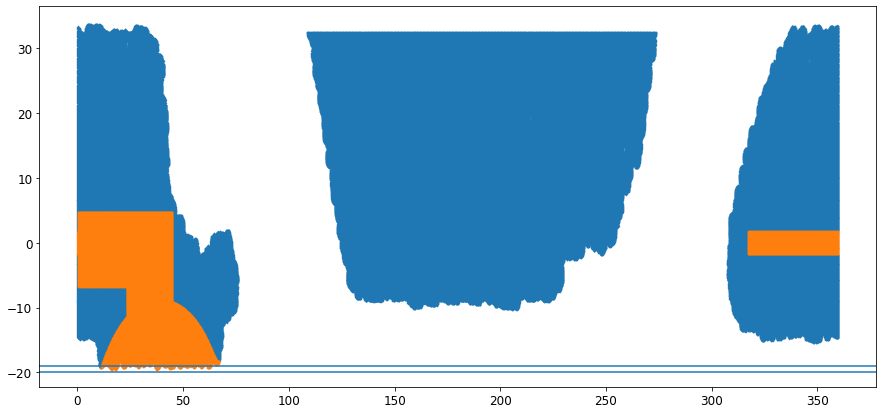

In [15]:
decals = (maps['PHOTSYS']=='S') & (~indes) & indesi
des = (maps['PHOTSYS']=='S') & indes & indesi
area_decals = np.sum(maps['FRACAREA'][decals]) * pix_area
area_des = np.sum(maps['FRACAREA'][des]) * pix_area

plt.figure(figsize=(15, 7))
plt.plot(maps['RA'][decals], maps['DEC'][decals], '.', ms=1)
plt.plot(maps['RA'][des], maps['DEC'][des], '.', ms=1)
plt.axhline(-20)
plt.axhline(-19)
plt.show()

In [17]:
dens_in_decals = np.sum(maps['n_targets'][decals])/area_decals
print('Density in DESI North: {:.1f} per sq. deg.'.format(dens_in_decals))

dens_in_des = np.sum(maps['n_targets'][des])/area_des
print('Density in DESI South: {:.1f} per sq. deg.'.format(dens_in_des))

Density in DESI North: 608.1 per sq. deg.
Density in DESI South: 589.4 per sq. deg.


In [21]:
1-589.4/608.1

0.0307515211313929

LRG density is ~3% lower in DES than in DECaLS.

-----

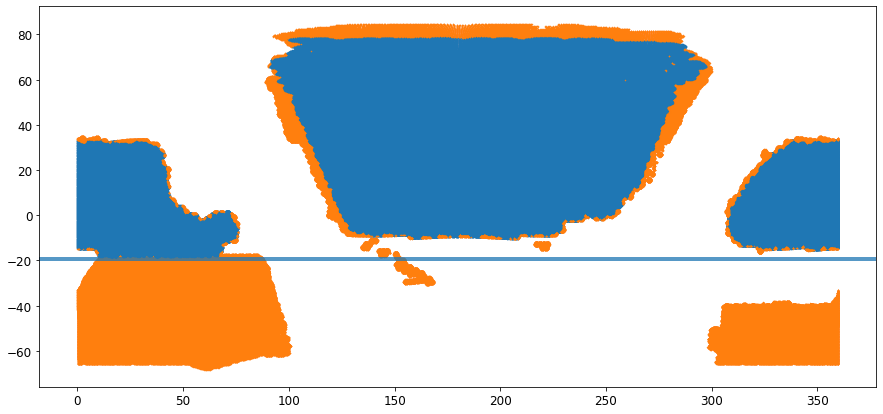

In [8]:
plt.figure(figsize=(15, 7))
plt.plot(maps['RA'][indesi], maps['DEC'][indesi], '.', ms=1)
plt.plot(maps['RA'][~indesi], maps['DEC'][~indesi], '.', ms=1)
plt.axhline(-20, lw=1, color='k')
plt.axhline(-19, lw=1, color='k')
plt.show()

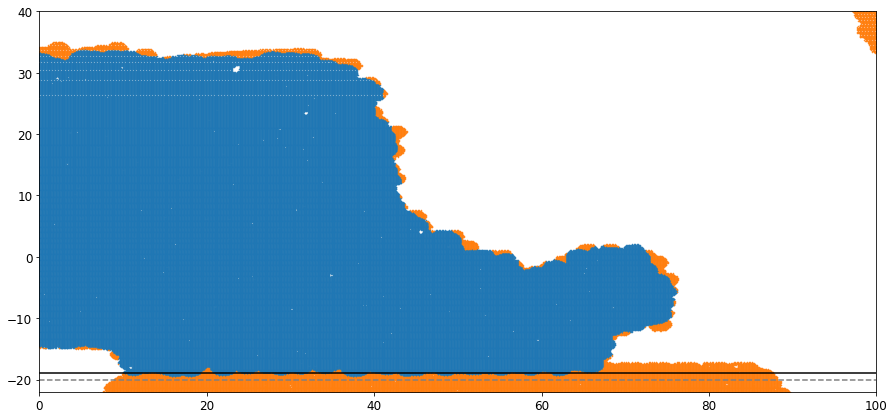

In [9]:
plt.figure(figsize=(15, 7))
plt.plot(maps['RA'][indesi], maps['DEC'][indesi], '.', ms=1)
plt.plot(maps['RA'][~indesi], maps['DEC'][~indesi], '.', ms=1)
plt.axis([0, 100, -22,40])
plt.axhline(-19, color='black')
plt.axhline(-20, ls='--', color='gray')
plt.show()

--------
## Number of LRGs observed in SV1 and SV3

In [15]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))
print('SV1', len(cat), len(np.unique(cat['TARGETID'])))
# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]
print('SV1', len(cat), len(np.unique(cat['TARGETID'])))

SV1 55235 54987
COADD_FIBERSTATUS 46319 8916 0.16141938987960533
SV1 46319 46151


In [16]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv3_cumulative_lrg.fits'))
print('SV3', len(cat), len(np.unique(cat['TARGETID'])))
# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]
print('SV3', len(cat), len(np.unique(cat['TARGETID'])))

SV3 182622 142760
COADD_FIBERSTATUS 164618 18004 0.09858615062807329
SV3 164618 140226
